In [447]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


In [448]:
df=pd.read_csv("/content/drive/MyDrive/eda/Diwali Sales Data.csv",encoding="unicode_escape")

In [449]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [450]:
df.shape

(11251, 15)

In [451]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


data cleaning

dropping unnecessary column

In [452]:
df=df.drop(columns=['unnamed1','Status'])

In [453]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


Checking duplicates

In [454]:
df.duplicated().sum()

np.int64(8)

checking null value

In [455]:
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [456]:
df['Amount'].dtypes

dtype('float64')

In [457]:
df['Amount'] = df['Amount'].fillna(df['Amount'].median())

In [458]:
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [459]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


Bivariate Analysis

<Axes: xlabel='Gender', ylabel='count'>

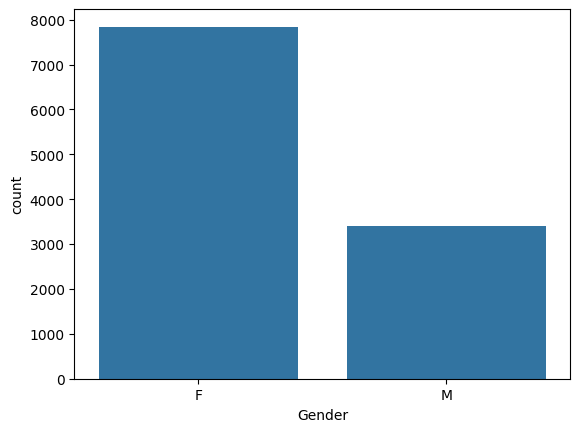

In [460]:
sns.countplot(df,x='Gender')

<Axes: xlabel='Marital_Status'>

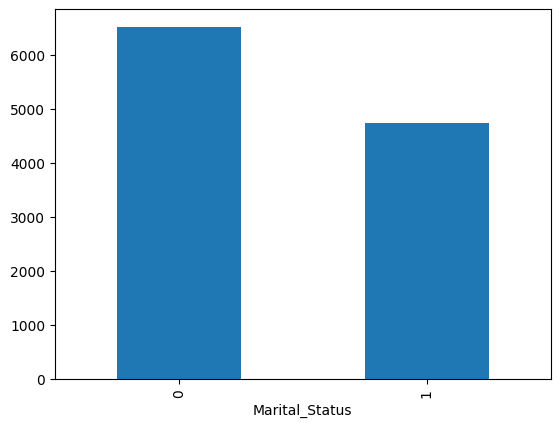

In [461]:
df['Marital_Status'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

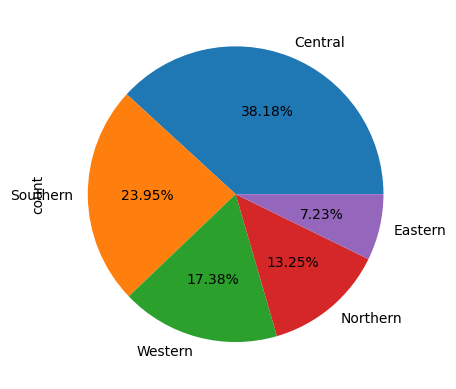

In [462]:
df['Zone'].value_counts().plot(kind='pie',autopct="%1.2f%%")

<Axes: xlabel='Orders'>

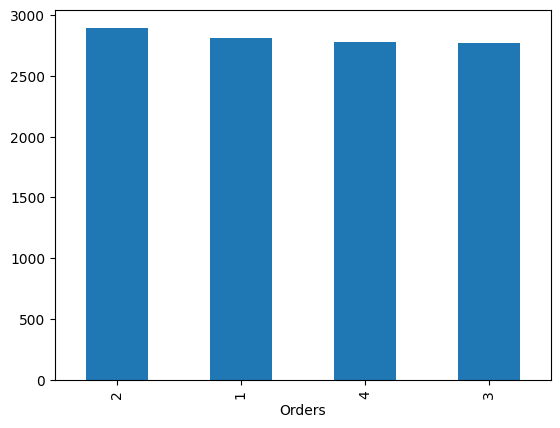

In [463]:
 df['Orders'].value_counts().plot(kind='bar')

Conclusion


Females purchase more goods than males.Unmarried people tend to make more purchases than married people.The Central Zone has the highest sales compared to other zones. Customers tend to order a quantity of 2 more frequently.


---







<Axes: xlabel='Age', ylabel='Count'>

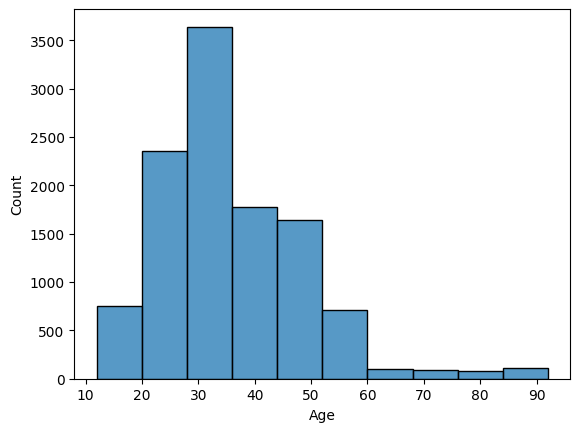

In [464]:
sns.histplot(df,x='Age',bins=10)

In [465]:
df['Age'].skew()

np.float64(1.183203633076307)

<Axes: xlabel='Age', ylabel='Count'>

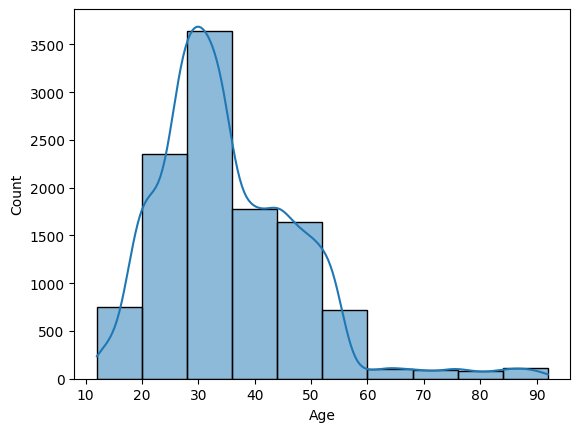

In [466]:
sns.histplot(df,x='Age',kde=True,bins=10)

Most customers are between approximately 20–50 years old.
The highest concentration is around 25–35 years.
There are relatively few older customers above 60.
The long tail toward higher ages causes the positive skewness.

<Axes: xlabel='Amount', ylabel='Count'>

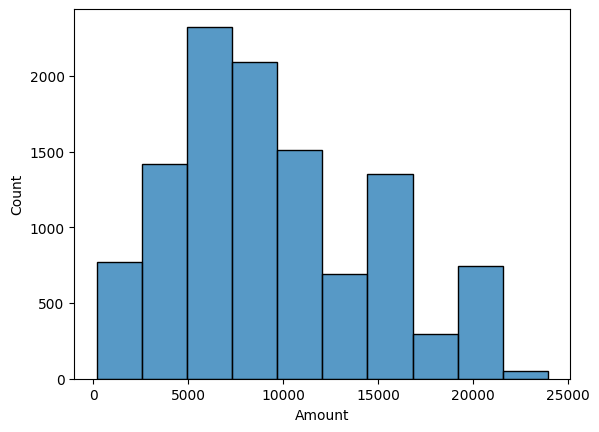

In [467]:
sns.histplot(df,x='Amount',bins=10)

<Axes: xlabel='Amount', ylabel='Count'>

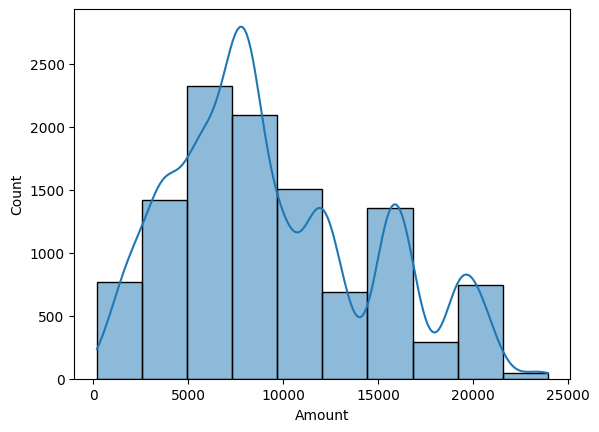

In [468]:
sns.histplot(df,x='Amount',kde=True,bins=10)

In [469]:
df['Amount'].skew()

np.float64(0.5590704261690377)

The Amount distribution is right-skewed, with most transactions concentrated in the 5,000–10,000 range. Higher-value transactions are less frequent, with a small number extending beyond 20,000

<Axes: xlabel='Age'>

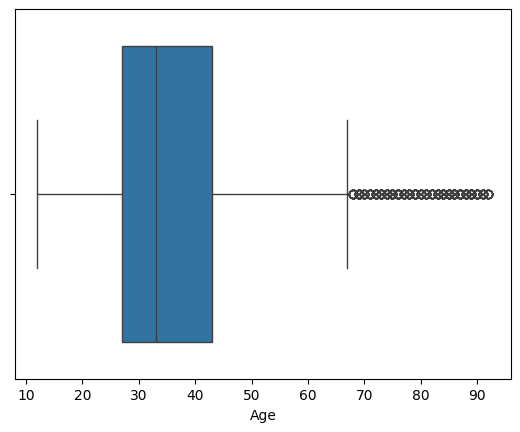

In [470]:
sns.boxplot(df,x='Age')

The boxplot indicates that most customers are between approximately 27 and 43 years old, with a median age of around 33. Several high-age observations above approximately 67 years appear as outliers, contributing to the right-skewed distribution.

Bivariate and multivariate

In [471]:
pd.crosstab(df['Zone'],df['Gender'])

Gender,F,M
Zone,,
Central,2961,1335
Eastern,567,247
Northern,1031,460
Southern,1865,830
Western,1418,537


In [472]:
pd.crosstab(df['Zone'],df['Gender'],normalize='columns')*100

Gender,F,M
Zone,,
Central,37.758225,39.161044
Eastern,7.230298,7.245527
Northern,13.147156,13.493693
Southern,23.782198,24.347316
Western,18.082122,15.752420


<Axes: xlabel='Gender', ylabel='Zone'>

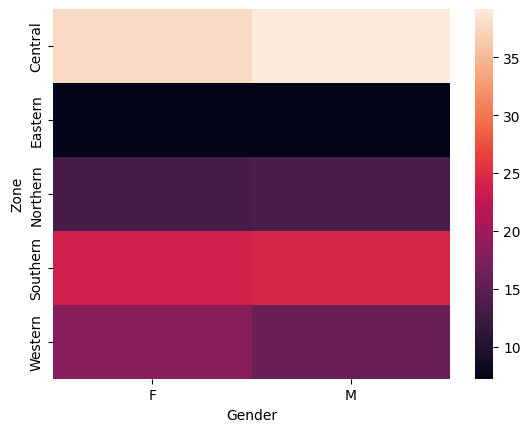

In [473]:
sns.heatmap(pd.crosstab(df['Zone'],df['Gender'],normalize='columns')*100)

The Central Zone has the highest share of both female and male customers, while the Eastern Zone has the lowest share. The Southern Zone has the second-highest share for both genders. Overall, the distribution of females and males across the zones is relatively similar.

In [474]:
top_5=df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False).head(3).reset_index()
top_5

,Product_Category,Amount
0,Food,33958210.5
1,Clothing & Apparel,16495019.0
2,Electronics & Gadgets,15643846.0


In [475]:
px.bar(top_5,x='Product_Category',y='Amount')

Food is the top-selling product category by a wide margin, generating 34M in sales — more than double Clothing & Apparel (16.5M) and Electronics & Gadgets (15.6M), which are close to each other in second and third place.

<Axes: xlabel='Zone', ylabel='Amount'>

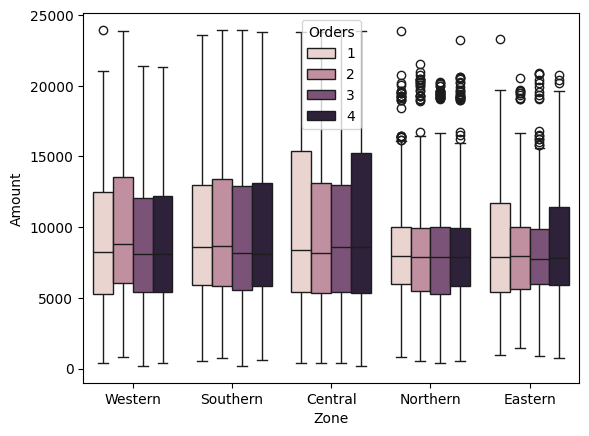

In [476]:
sns.boxplot(df,x='Zone',y='Amount',hue='Orders')

Order amount distributions are fairly similar in median across all zones (roughly 7,500–10,000), regardless of the number of orders placed. Central zone stands out with the highest overall spread and median amounts, especially for single and 4-order transactions. Northern and Eastern zones show many more high-value outliers (20,000+), indicating occasional large transactions that pull well above the typical range. Western zone has the tightest, most consistent distribution with fewer extreme outliers.